In [ ]:
# Ноутбук перенесён в подпапку — восстанавливаем CWD в корень thesis/
import os
from pathlib import Path

if Path.cwd().name != "thesis":
    os.chdir("..")
print("CWD:", Path.cwd())


# Fine-tuning Bi-Encoder (Augmented SBERT — Step 2.1)

Дообучение bi-encoder `ai-forever/ru-en-RoSBERTa` на **объединённом** gold_train + silver dataset (Augmented SBERT, Section 3.1).

**Пайплайн Augmented SBERT (Thakur et al., 2021):**
1. ~~Fine-tune Cross-Encoder на gold dataset~~ (done, Spearman 0.385 → 0.728)
2. ~~Разметить silver dataset с помощью CE~~ (done, ~1.26M пар)
3. ~~Балансировка silver + объединение с gold_train~~ (done, silver-balancing.ipynb)
4. **Fine-tune Bi-Encoder на gold_train + silver** ← этот ноутбук
5. Production: Bi-Encoder retrieval + Cross-Encoder re-ranking

**Ключевое изменение:** Предыдущая версия обучала bi-encoder **только** на silver data.
Статья требует объединить silver с gold train split: *"silver dataset will be merged with the gold training dataset"*.

**Обоснование выбора параметров:** `notes/bi_encoder_params.md`

In [3]:
# ============================================================
# Конфигурация — все параметры в одном месте
# ============================================================

BASE_MODEL = "bi_encoder_rawT"                        # локальная копия ai-forever/ru-en-RoSBERTa
OUTPUT_DIR = "models/bi-encoder-training"              # checkpoints во время обучения
FINAL_MODEL_DIR = "models/final/bi-encoder"            # финальная модель после обучения

# Данные (из silver-balancing.ipynb, секция 6)
TRAIN_DATA = "data/silver/train_gold_silver.parquet"   # gold_train + silver_balanced (merged)
EVAL_DATA = "data/golden/golden_eval.parquet"          # gold_eval (20% от golden_pairs.csv)

BATCH_SIZE = 64
LEARNING_RATE = 2e-5
NUM_EPOCHS = 4                                         # увеличено с 1 до 4 (как cross-encoder)
WARMUP_RATIO = 0.1
EVAL_STEPS = 500
SAVE_STEPS = 500
SAVE_TOTAL_LIMIT = 3
LOGGING_STEPS = 50
SEED = 42

## 1. Загрузка и подготовка данных

### 1.1 Train dataset (gold_train + silver_balanced)

Загружаем объединённый датасет из `silver-balancing.ipynb` (секция 6).  
Содержит gold_train (80% golden data) + silver_balanced (29,660 пар).  
Это соответствует Augmented SBERT (Section 3.1): *"silver dataset will be merged with the gold training dataset"*.

In [4]:
import os
from datasets import load_dataset

assert os.path.exists(TRAIN_DATA), f"Сначала запустите silver-balancing.ipynb (секция 6) — файл {TRAIN_DATA} не найден"

train_dataset = load_dataset("parquet", data_files=TRAIN_DATA, split="train")

print(f"Train dataset: {len(train_dataset):,} пар (gold_train + silver_balanced)")
print(f"Колонки: {train_dataset.column_names}")
print(train_dataset[0])

Train dataset: 36,048 пар (gold_train + silver_balanced)
Колонки: ['product_desc', 'post_text', 'score']
{'product_desc': 'Качественная фабричная обувь создана для защиты от кораллов, острых камней ,горячего песка и морских ежей, также надежно защищают от порезов. Прекрасно подходят для занятия морскими видами спорта. Очень удобны и практичны.', 'post_text': 'Пока ничего )) лежу, жду врача, жду Катю, есть ничего не получается ( начинаю смотреть отчаянных домохозяек )) сначала Гринуля о них напомнила, а потом недавно залипла на маникюре и решила, что так и быть - пересмотрю!', 'score': 0.0}


### 1.2 EDA: распределение score в merged train dataset

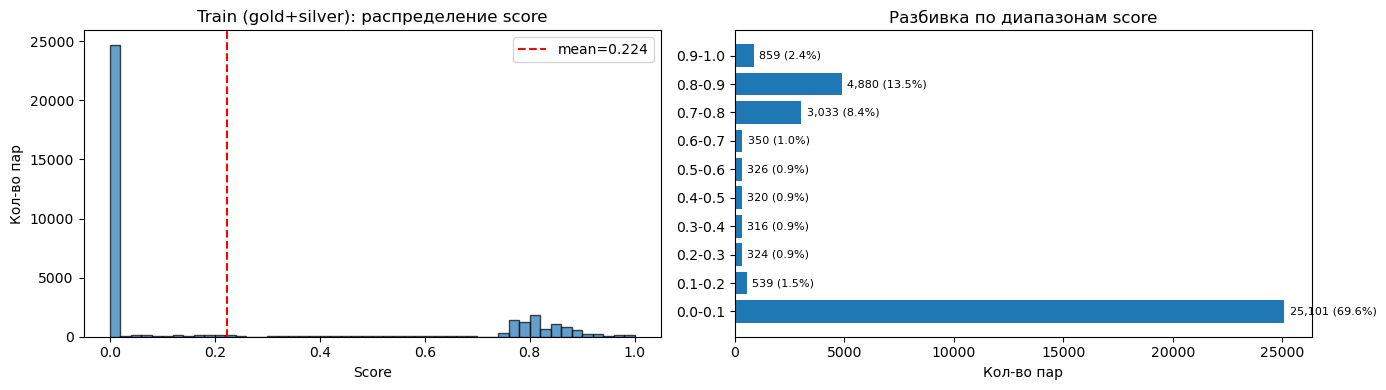

Всего пар: 36,048
Mean: 0.2236, Median: 0.0000, Std: 0.3557
Min: 0.0000, Max: 1.0000
Score = 0: 24,627 (68.3%)
Score > 0: 11,421 (31.7%)
Score > 0.5: 9,413 (26.1%)


In [5]:
import matplotlib.pyplot as plt
import numpy as np

scores = np.array(train_dataset["score"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Гистограмма
axes[0].hist(scores, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Кол-во пар")
axes[0].set_title("Train (gold+silver): распределение score")
axes[0].axvline(scores.mean(), color="red", linestyle="--", label=f"mean={scores.mean():.3f}")
axes[0].legend()

# Статистика по бинам
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01]
counts, _ = np.histogram(scores, bins=bins)
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]
axes[1].barh(labels, counts)
axes[1].set_xlabel("Кол-во пар")
axes[1].set_title("Разбивка по диапазонам score")
for i, c in enumerate(counts):
    axes[1].text(c + max(counts)*0.01, i, f"{c:,} ({c/len(scores)*100:.1f}%)", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Всего пар: {len(scores):,}")
print(f"Mean: {scores.mean():.4f}, Median: {np.median(scores):.4f}, Std: {scores.std():.4f}")
print(f"Min: {scores.min():.4f}, Max: {scores.max():.4f}")
print(f"Score = 0: {(scores == 0).sum():,} ({(scores == 0).mean()*100:.1f}%)")
print(f"Score > 0: {(scores > 0).sum():,} ({(scores > 0).mean()*100:.1f}%)")
print(f"Score > 0.5: {(scores > 0.5).sum():,} ({(scores > 0.5).mean()*100:.1f}%)")

### 1.3 Golden eval dataset

20% golden data, отделённых в silver-balancing.ipynb. Не пересекается с gold_train, который вошёл в train.

In [6]:
assert os.path.exists(EVAL_DATA), f"Сначала запустите silver-balancing.ipynb (секция 6) — файл {EVAL_DATA} не найден"

eval_dataset = load_dataset("parquet", data_files=EVAL_DATA, split="train")

print(f"Eval dataset: {len(eval_dataset)} пар (gold_eval, 20% от golden_pairs.csv)")
print(f"Колонки: {eval_dataset.column_names}")
print(f"Score range: [{min(eval_dataset['score']):.2f}, {max(eval_dataset['score']):.2f}]")
print(eval_dataset[0])

Eval dataset: 1598 пар (gold_eval, 20% от golden_pairs.csv)
Колонки: ['product_desc', 'post_text', 'score']
Score range: [0.00, 1.00]
{'product_desc': 'Получите уникальный шанс окунуться в атмосферу любимых сериалов раньше всех! Приложение CinemaStream предлагает эксклюзивный доступ к первым эпизодам популярных шоу, включая новые сезоны популярных комедий и драм. Специальная подписка позволит вам смотреть любимые проекты без рекламы и ограничений, наслаждаясь отличным контентом с удобством и комфортом.', 'post_text': 'Друзья, пока я тут помаленьку кую текстовый и видеоконтент, советую посмотреть только что вышедший фильм «За пивом». Картина снята на основе знаменитой истории про ветерана Джона «Чики» Донохью, который на спор отправился во Вьетнам с запасом пива, чтобы угостить им боевых товарищей.Ленту снял режиссер «Зеленой книги» Питер Фаррелли, в ролях прекраснык Зак Эфрон, Рассел Кроу и Билл Мюррей.Очень рекомендую! Официально доступно на Apple TV+, а также на куче неофициальных пл

## 2. Модель и Loss

In [7]:
# Совместимость sentence-transformers 5.1.2 + transformers 4.57.x
import transformers
from transformers.modeling_utils import PreTrainedModel
transformers.PreTrainedModel = PreTrainedModel

from sentence_transformers import SentenceTransformer
from sentence_transformers.losses import CoSENTLoss

# Обход проверки torch >= 2.6 при загрузке чекпоинтов (CVE-2025-32434)
# Безопасно: загружаем только свои локальные чекпоинты
import sys
_noop = lambda: None
for _mod in sys.modules.values():
    if hasattr(_mod, 'check_torch_load_is_safe'):
        _mod.check_torch_load_is_safe = _noop

model = SentenceTransformer(BASE_MODEL)

print(f"Модель: {BASE_MODEL}")
print(f"Max seq length: {model.max_seq_length}")
print(f"Embedding dim: {model.get_sentence_embedding_dimension()}")
print(f"Similarity: {model.similarity_fn_name}")

loss = CoSENTLoss(model)
print(f"\nLoss: CoSENTLoss")

Модель: bi_encoder_rawT
Max seq length: 8192
Embedding dim: 384
Similarity: cosine

Loss: CoSENTLoss


## 3. Evaluator и baseline

Считаем Spearman до обучения, чтобы потом сравнить.

In [8]:
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator, SimilarityFunction

# Колонка product_desc (переименована из description в silver-balancing.ipynb)
eval_col1 = "product_desc" if "product_desc" in eval_dataset.column_names else "description"

evaluator = EmbeddingSimilarityEvaluator(
    sentences1=eval_dataset[eval_col1],
    sentences2=eval_dataset["post_text"],
    scores=eval_dataset["score"],
    batch_size=BATCH_SIZE,
    main_similarity=SimilarityFunction.COSINE,
    name="golden",
    show_progress_bar=True,
)

print("Baseline (до обучения):")
baseline_results = evaluator(model)
baseline_spearman = baseline_results["golden_spearman_cosine"]
print(f"  Spearman (cosine): {baseline_spearman:.4f}")
print(f"  Pearson  (cosine): {baseline_results['golden_pearson_cosine']:.4f}")

Baseline (до обучения):


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

  Spearman (cosine): -0.0297
  Pearson  (cosine): 0.0329


## 4. Обучение

Обучение можно прервать и продолжить: при перезапуске этой ячейки обучение автоматически возобновится с последнего сохранённого checkpoint-а.

In [9]:
from sentence_transformers import SentenceTransformerTrainingArguments

args = SentenceTransformerTrainingArguments(
    output_dir=OUTPUT_DIR,

    # Длительность
    num_train_epochs=NUM_EPOCHS,

    # Батч
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,

    # Оптимизатор
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=0.01,

    # Память
    gradient_checkpointing=True,
    dataloader_num_workers=0,         # Windows

    # Eval
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    load_best_model_at_end=True,
    metric_for_best_model="eval_golden_spearman_cosine",
    greater_is_better=True,

    # Checkpoints
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,

    # Логирование
    logging_steps=LOGGING_STEPS,

    # Воспроизводимость
    seed=SEED,
    data_seed=SEED,

    # Детерминированный DataLoader (для точного resume)
    dataloader_drop_last=True,
)

total_steps = (len(train_dataset) // BATCH_SIZE) * NUM_EPOCHS
print(f"Ожидаемое кол-во шагов: ~{total_steps:,}")
print(f"Eval каждые {EVAL_STEPS} шагов = ~{total_steps // EVAL_STEPS} раз за обучение")

Ожидаемое кол-во шагов: ~2,252
Eval каждые 500 шагов = ~4 раз за обучение


In [10]:
from sentence_transformers import SentenceTransformerTrainer

trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    loss=loss,
    evaluator=evaluator,
)

# Автоматический resume: если в OUTPUT_DIR есть checkpoint — продолжить с него
has_checkpoint = (
    os.path.isdir(OUTPUT_DIR)
    and any(d.startswith("checkpoint-") for d in os.listdir(OUTPUT_DIR))
)

if has_checkpoint:
    print("Найден checkpoint, продолжаем обучение...")
else:
    print("Checkpoint не найден, начинаем с нуля...")

trainer.train(resume_from_checkpoint=has_checkpoint if has_checkpoint else None)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Найден checkpoint, продолжаем обучение...


Step,Training Loss,Validation Loss


TrainOutput(global_step=2252, training_loss=0.0, metrics={'train_runtime': 0.3951, 'train_samples_per_second': 364996.13, 'train_steps_per_second': 5700.533, 'total_flos': 0.0, 'train_loss': 0.0, 'epoch': 4.0})

## 5. Сохранение и оценка результатов

In [11]:
model.save_pretrained(FINAL_MODEL_DIR)
print(f"Финальная модель сохранена: {FINAL_MODEL_DIR}")

Финальная модель сохранена: models/final/bi-encoder


In [12]:
print("Финальная оценка на golden dataset:")
final_results = evaluator(model)
final_spearman = final_results["golden_spearman_cosine"]
final_pearson = final_results["golden_pearson_cosine"]

print(f"\n{'='*50}")
print(f"{'РЕЗУЛЬТАТЫ':^50}")
print(f"{'='*50}")
print(f"{'Метрика':<25} {'До обучения':>12} {'После':>12} {'Delta':>12}")
print(f"{'-'*50}")
print(f"{'Spearman (cosine)':<25} {baseline_spearman:>12.4f} {final_spearman:>12.4f} {final_spearman - baseline_spearman:>+12.4f}")
print(f"{'Pearson (cosine)':<25} {baseline_results['golden_pearson_cosine']:>12.4f} {final_pearson:>12.4f} {final_pearson - baseline_results['golden_pearson_cosine']:>+12.4f}")
print(f"{'='*50}")
print(f"\nCross-Encoder Spearman на golden: 0.7280 (ориентир)")

Финальная оценка на golden dataset:


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]


                    РЕЗУЛЬТАТЫ                    
Метрика                    До обучения        После        Delta
--------------------------------------------------
Spearman (cosine)              -0.0297       0.3934      +0.4231
Pearson (cosine)                0.0329       0.3951      +0.3622

Cross-Encoder Spearman на golden: 0.7280 (ориентир)


## 6. Smoke test

Быстрая проверка: encode описание товара, найти ближайшие посты по cosine similarity.

In [13]:
from sentence_transformers.util import cos_sim

# Несколько пар из golden eval для визуальной проверки
test_indices = [0, 100, 500, 1000, min(len(eval_dataset)-1, 2000)]

eval_col1 = "product_desc" if "product_desc" in eval_dataset.column_names else "description"

descriptions = [eval_dataset[i][eval_col1] for i in test_indices]
posts = [eval_dataset[i]["post_text"] for i in test_indices]
gold_scores = [eval_dataset[i]["score"] for i in test_indices]

emb_desc = model.encode(descriptions, convert_to_tensor=True)
emb_post = model.encode(posts, convert_to_tensor=True)

for i, idx in enumerate(test_indices):
    sim = float(cos_sim(emb_desc[i], emb_post[i]))
    print(f"Пара #{idx}: gold={gold_scores[i]:.2f}, cosine_sim={sim:.4f}")
    print(f"  Desc: {descriptions[i][:80]}...")
    print(f"  Post: {posts[i][:80]}...")
    print()

Пара #0: gold=0.00, cosine_sim=0.8490
  Desc: Получите уникальный шанс окунуться в атмосферу любимых сериалов раньше всех! При...
  Post: Друзья, пока я тут помаленьку кую текстовый и видеоконтент, советую посмотреть т...

Пара #100: gold=0.25, cosine_sim=0.8322
  Desc: Превосходная кофемашина Nespresso, обеспечивающая идеальный вкус ароматного кофе...
  Post: Аватар В этом году вышел долгожданный Аватар. Этого момента ждали больше 10 лет....

Пара #500: gold=0.85, cosine_sim=0.8972
  Desc: Профессиональная серия средств ухода за полостью рта для тех, кто носит брекеты ...
  Post: Пожелайте мне удачи, у меня сегодня первая активация у ортодонта, вставят другую...

Пара #1000: gold=0.00, cosine_sim=0.8484
  Desc: Настройка психологической устойчивости и уверенности для спортсменов и публичных...
  Post: Подъемы на носкиОсновная группа мышц: ИкроножныеКоличество: 4 подхода по 20 повт...

Пара #1597: gold=0.62, cosine_sim=0.8962
  Desc: Подарочный набор чайных трав поможет расслабиться и 